# SOH Driver Analysis From Event Timeseries

This notebook looks for telemetry variables that may help explain the observed SOH spike behavior.

Approach:
- Aggregate raw event-timeseries telemetry to one row per flight, timestamp, and battery
- Compute observed SOH per flight from ` bat 1 soh` / ` bat 2 soh`
- Build candidate driver features from temperature, OAT, voltage, current, SOC, and a few flight variables
- Rank candidate variables by correlation with SOH
- Plot rolling standardized time-series overlays and scatter plots against SOH

This is intended to identify which variables move with the SOH spikes, not to prove causality by itself.

In [41]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)


def find_path(*relative_candidates: str) -> Path:
    search_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    for root in search_roots:
        for relative in relative_candidates:
            candidate = (root / relative).resolve()
            if candidate.exists():
                return candidate
    raise FileNotFoundError(f'Could not find any of: {relative_candidates}')


timeseries_path = find_path('data/event_timeseries.parquet', 'data/processed/event_timeseries.parquet')
PLANES = ['166', '192']
ROLLING_WINDOW = 5

timeseries_path


PosixPath('/Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/data/event_timeseries.parquet')

In [42]:
def zscore(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors='coerce')
    std = s.std(skipna=True)
    if pd.isna(std) or float(std) <= 1e-12:
        return pd.Series(np.nan, index=s.index)
    return (s - s.mean(skipna=True)) / std


def corr_pair(x: pd.Series, y: pd.Series) -> tuple[int, float, float]:
    pair = pd.DataFrame({'x': pd.to_numeric(x, errors='coerce'), 'y': pd.to_numeric(y, errors='coerce')}).dropna()
    if len(pair) < 3:
        return int(len(pair)), np.nan, np.nan
    pearson = float(pair['x'].corr(pair['y'], method='pearson'))
    spearman = float(spearmanr(pair['x'], pair['y']).statistic)
    return int(len(pair)), pearson, spearman


def load_event_level_features(plane_id: str) -> pd.DataFrame:
    cols = [
        'plane_id', 'flight_id', 'event_datetime',
        ' bat 1 soh', ' bat 2 soh',
        ' bat 1 avg cell temp', ' bat 2 avg cell temp',
        ' OAT',
        ' bat 1 current', ' bat 2 current',
        ' bat 1 voltage', ' bat 2 voltage',
        ' bat 1 soc', ' bat 2 soc',
        ' bat 1 min cell volt', ' bat 2 min cell volt',
        ' bat 1 max cell volt', ' bat 2 max cell volt',
        ' motor power', ' IAS', ' remaining flight time', ' inverter temp', ' motor temp',
    ]
    df = pd.read_parquet(timeseries_path, columns=cols, filters=[('plane_id', '==', plane_id)]).copy()
    df['event_datetime'] = pd.to_datetime(df['event_datetime'])
    df = df.rename(columns={
        ' bat 1 soh': 'battery_1_soh',
        ' bat 2 soh': 'battery_2_soh',
        ' bat 1 avg cell temp': 'battery_1_temp_c',
        ' bat 2 avg cell temp': 'battery_2_temp_c',
        ' OAT': 'oat_c',
        ' bat 1 current': 'battery_1_current_a',
        ' bat 2 current': 'battery_2_current_a',
        ' bat 1 voltage': 'battery_1_voltage_v',
        ' bat 2 voltage': 'battery_2_voltage_v',
        ' bat 1 soc': 'battery_1_soc_pct',
        ' bat 2 soc': 'battery_2_soc_pct',
        ' bat 1 min cell volt': 'battery_1_cell_v_min',
        ' bat 2 min cell volt': 'battery_2_cell_v_min',
        ' bat 1 max cell volt': 'battery_1_cell_v_max',
        ' bat 2 max cell volt': 'battery_2_cell_v_max',
        ' motor power': 'motor_power_kw',
        ' IAS': 'ias',
        ' remaining flight time': 'remaining_flight_time_min',
        ' inverter temp': 'inverter_temp_c',
        ' motor temp': 'motor_temp_c',
    })

    placeholder_zero_cols = [
        'battery_1_soh', 'battery_2_soh',
        'battery_1_temp_c', 'battery_2_temp_c',
        'oat_c',
        'battery_1_voltage_v', 'battery_2_voltage_v',
        'battery_1_soc_pct', 'battery_2_soc_pct',
        'battery_1_cell_v_min', 'battery_2_cell_v_min',
        'battery_1_cell_v_max', 'battery_2_cell_v_max',
    ]
    for col in placeholder_zero_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce').replace(0, pd.NA)
    numeric_cols = [
        'battery_1_current_a', 'battery_2_current_a', 'motor_power_kw', 'ias',
        'remaining_flight_time_min', 'inverter_temp_c', 'motor_temp_c'
    ]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    shared_event = (
        df.groupby(['plane_id', 'flight_id', 'event_datetime'], as_index=False)
        .agg(
            oat_mean_c=('oat_c', 'mean'),
            motor_power_mean_kw=('motor_power_kw', 'mean'),
            motor_power_abs_mean_kw=('motor_power_kw', lambda s: pd.to_numeric(s, errors='coerce').abs().mean()),
            ias_mean=('ias', 'mean'),
            remaining_flight_time_mean_min=('remaining_flight_time_min', 'mean'),
            inverter_temp_mean_c=('inverter_temp_c', 'mean'),
            motor_temp_mean_c=('motor_temp_c', 'mean'),
        )
    )

    parts = []
    for battery_id in [1, 2]:
        soh_col = f'battery_{battery_id}_soh'
        temp_col = f'battery_{battery_id}_temp_c'
        current_col = f'battery_{battery_id}_current_a'
        voltage_col = f'battery_{battery_id}_voltage_v'
        soc_col = f'battery_{battery_id}_soc_pct'
        cell_v_min_col = f'battery_{battery_id}_cell_v_min'
        cell_v_max_col = f'battery_{battery_id}_cell_v_max'

        battery_event = (
            df.groupby(['plane_id', 'flight_id', 'event_datetime'], as_index=False)
            .agg(
                observed_soh_pct=(soh_col, 'median'),
                avg_cell_temp_c=(temp_col, 'mean'),
                current_mean_a=(current_col, 'mean'),
                current_abs_mean_a=(current_col, lambda s: pd.to_numeric(s, errors='coerce').abs().mean()),
                voltage_mean_v=(voltage_col, 'mean'),
                voltage_max_v=(voltage_col, 'max'),
                soc_mean_pct=(soc_col, 'mean'),
                soc_min_pct=(soc_col, 'min'),
                soc_max_pct=(soc_col, 'max'),
                cell_v_min_mean=(cell_v_min_col, 'mean'),
                cell_v_max_mean=(cell_v_max_col, 'mean'),
            )
        )
        battery_event['soc_span_pct'] = battery_event['soc_max_pct'] - battery_event['soc_min_pct']
        battery_event['cell_v_spread_mean'] = battery_event['cell_v_max_mean'] - battery_event['cell_v_min_mean']
        battery_event['battery_id'] = battery_id
        parts.append(battery_event)

    out = pd.concat(parts, ignore_index=True)
    out = out.merge(shared_event, on=['plane_id', 'flight_id', 'event_datetime'], how='left')
    out = out.dropna(subset=['observed_soh_pct']).sort_values(['plane_id', 'battery_id', 'event_datetime']).reset_index(drop=True)
    return out


event_df = pd.concat([load_event_level_features(plane) for plane in PLANES], ignore_index=True)
event_df.head()


,plane_id,flight_id,event_datetime,observed_soh_pct,avg_cell_temp_c,current_mean_a,current_abs_mean_a,voltage_mean_v,voltage_max_v,soc_mean_pct,soc_min_pct,soc_max_pct,cell_v_min_mean,cell_v_max_mean,soc_span_pct,cell_v_spread_mean,battery_id,oat_mean_c,motor_power_mean_kw,motor_power_abs_mean_kw,ias_mean,remaining_flight_time_mean_min,inverter_temp_mean_c,motor_temp_mean_c
0,166,4575,2023-05-16 11:00:00,100.0,19.366222,-7.927996,7.928107,399.96939,404.0,92.911938,77.0,100.0,4160.481722,4173.621971,23.0,13.140249,1,NaN,0.000000,0.000000,0.000000,49.630016,0.000000,0.000000
1,166,4576,2023-05-16 12:44:00,100.0,21.982475,39.180481,39.191016,362.916307,401.9,68.777442,29.0,100.0,3776.960509,3791.663736,71.0,14.703227,1,16.938389,27.463047,27.463047,0.134558,23.682813,42.455124,55.722488
2,166,4577,2023-05-16 13:00:00,97.0,24.596219,-19.846659,19.846681,384.985389,403.9,70.793042,29.0,100.0,4006.252909,4015.357463,71.0,9.104554,1,NaN,0.000000,0.000000,0.000000,41.331806,0.000000,0.000000
3,166,4578,2023-05-16 14:35:00,97.0,23.50235,31.848112,31.850310,365.044653,400.5,66.627718,29.0,100.0,3800.597332,3811.928561,71.0,11.331229,1,20.39243,22.612595,22.612595,1.668098,29.205189,44.272494,56.467731
4,166,4579,2023-05-16 15:00:00,96.0,25.281313,-17.661869,17.661927,388.019645,404.5,74.672106,29.0,100.0,4037.195399,4047.266159,71.0,10.070761,1,NaN,0.000000,0.000000,0.000000,43.973523,0.000000,0.000000


In [43]:
candidate_metrics = [
    'avg_cell_temp_c',
    'oat_mean_c',
    'current_mean_a',
    'current_abs_mean_a',
    'voltage_mean_v',
    'voltage_max_v',
    'soc_mean_pct',
    'soc_min_pct',
    'soc_max_pct',
    'soc_span_pct',
    'cell_v_min_mean',
    'cell_v_max_mean',
    'cell_v_spread_mean',
    'motor_power_mean_kw',
    'motor_power_abs_mean_kw',
    'ias_mean',
    'remaining_flight_time_mean_min',
    'inverter_temp_mean_c',
    'motor_temp_mean_c',
]

rows = []
for (plane_id, battery_id), g in event_df.groupby(['plane_id', 'battery_id']):
    for metric in candidate_metrics:
        n, pearson, spearman = corr_pair(g['observed_soh_pct'], g[metric])
        rows.append({
            'plane_id': plane_id,
            'battery_id': battery_id,
            'metric': metric,
            'n_points': n,
            'pearson': pearson,
            'spearman': spearman,
            'abs_spearman': abs(spearman) if pd.notna(spearman) else np.nan,
        })

corr_df = pd.DataFrame(rows).sort_values(['plane_id', 'battery_id', 'abs_spearman'], ascending=[True, True, False]).reset_index(drop=True)
corr_df.head(20)


,plane_id,battery_id,metric,n_points,pearson,spearman,abs_spearman
0,166,1,cell_v_spread_mean,555,-0.119675,-0.261075,0.261075
1,166,1,soc_span_pct,555,0.155703,0.189168,0.189168
2,166,1,current_abs_mean_a,555,0.267787,0.175431,0.175431
3,166,1,soc_min_pct,555,-0.151151,-0.170220,0.170220
4,166,1,current_mean_a,555,0.216033,0.150767,0.150767
5,166,1,soc_mean_pct,555,-0.102197,-0.111005,0.111005
6,166,1,motor_power_mean_kw,555,0.100298,0.098355,0.098355
7,166,1,motor_power_abs_mean_kw,555,0.100298,0.098355,0.098355
8,166,1,avg_cell_temp_c,555,-0.060583,-0.088122,0.088122
9,166,1,soc_max_pct,555,0.029362,0.087543,0.087543


In [44]:
top_metrics = (
    corr_df.groupby('metric', as_index=False)
    .agg(mean_abs_spearman=('abs_spearman', 'mean'))
    .sort_values('mean_abs_spearman', ascending=False)
)
top_metrics


,metric,mean_abs_spearman
15,soc_min_pct,0.257779
0,avg_cell_temp_c,0.202361
12,remaining_flight_time_mean_min,0.191845
14,soc_mean_pct,0.182089
16,soc_span_pct,0.169128
13,soc_max_pct,0.161770
3,cell_v_spread_mean,0.137494
11,oat_mean_c,0.128905
1,cell_v_max_mean,0.125040
18,voltage_mean_v,0.122954


In [45]:
metrics_to_plot = top_metrics['metric'].head(6).tolist()
metrics_to_plot


['soc_min_pct',
 'avg_cell_temp_c',
 'remaining_flight_time_mean_min',
 'soc_mean_pct',
 'soc_span_pct',
 'soc_max_pct']

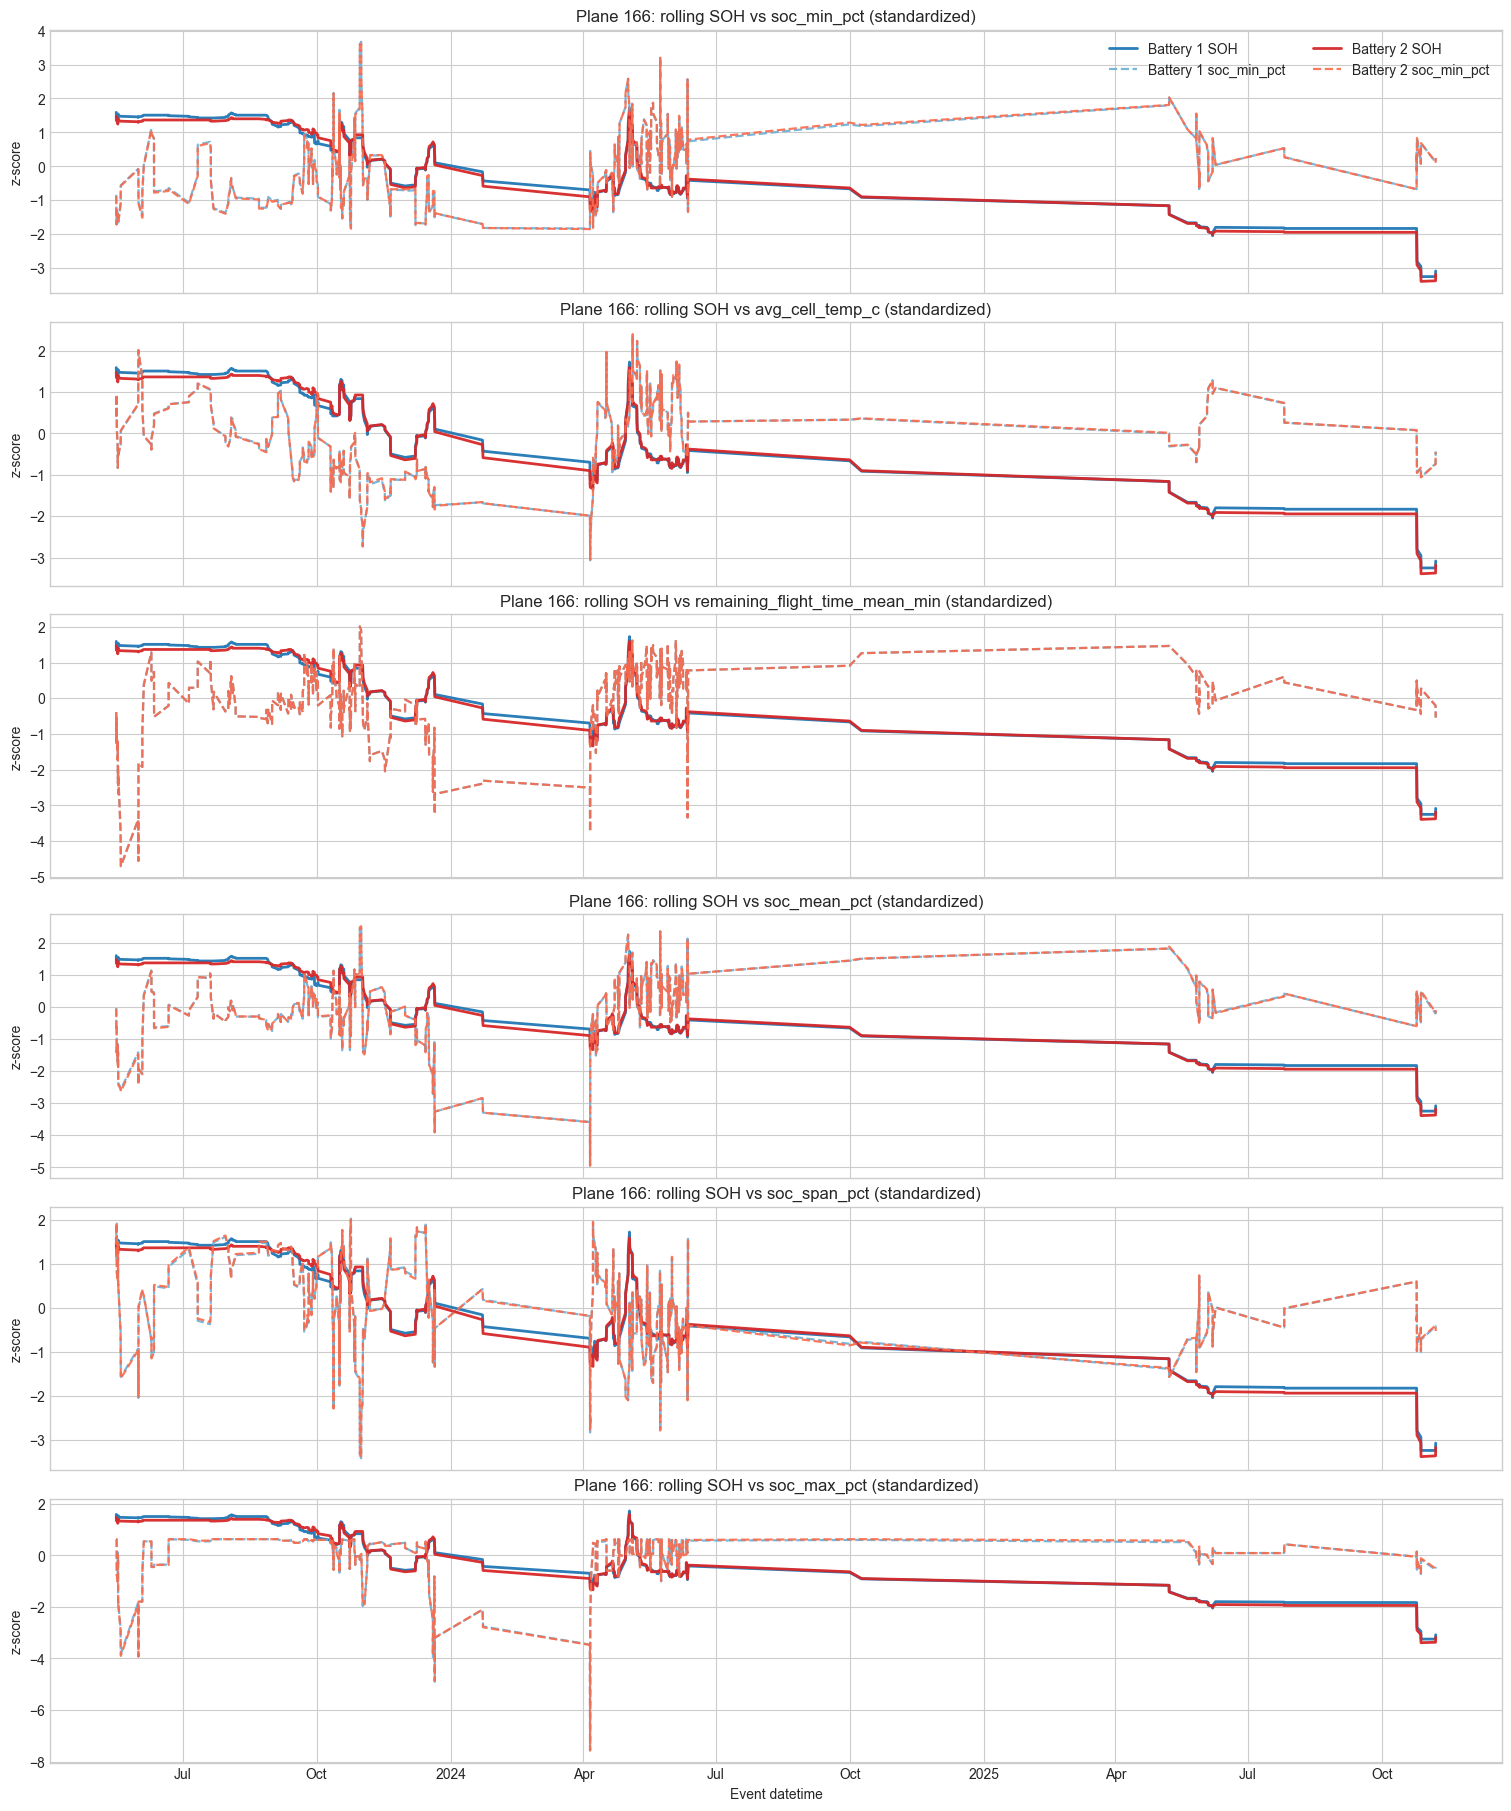

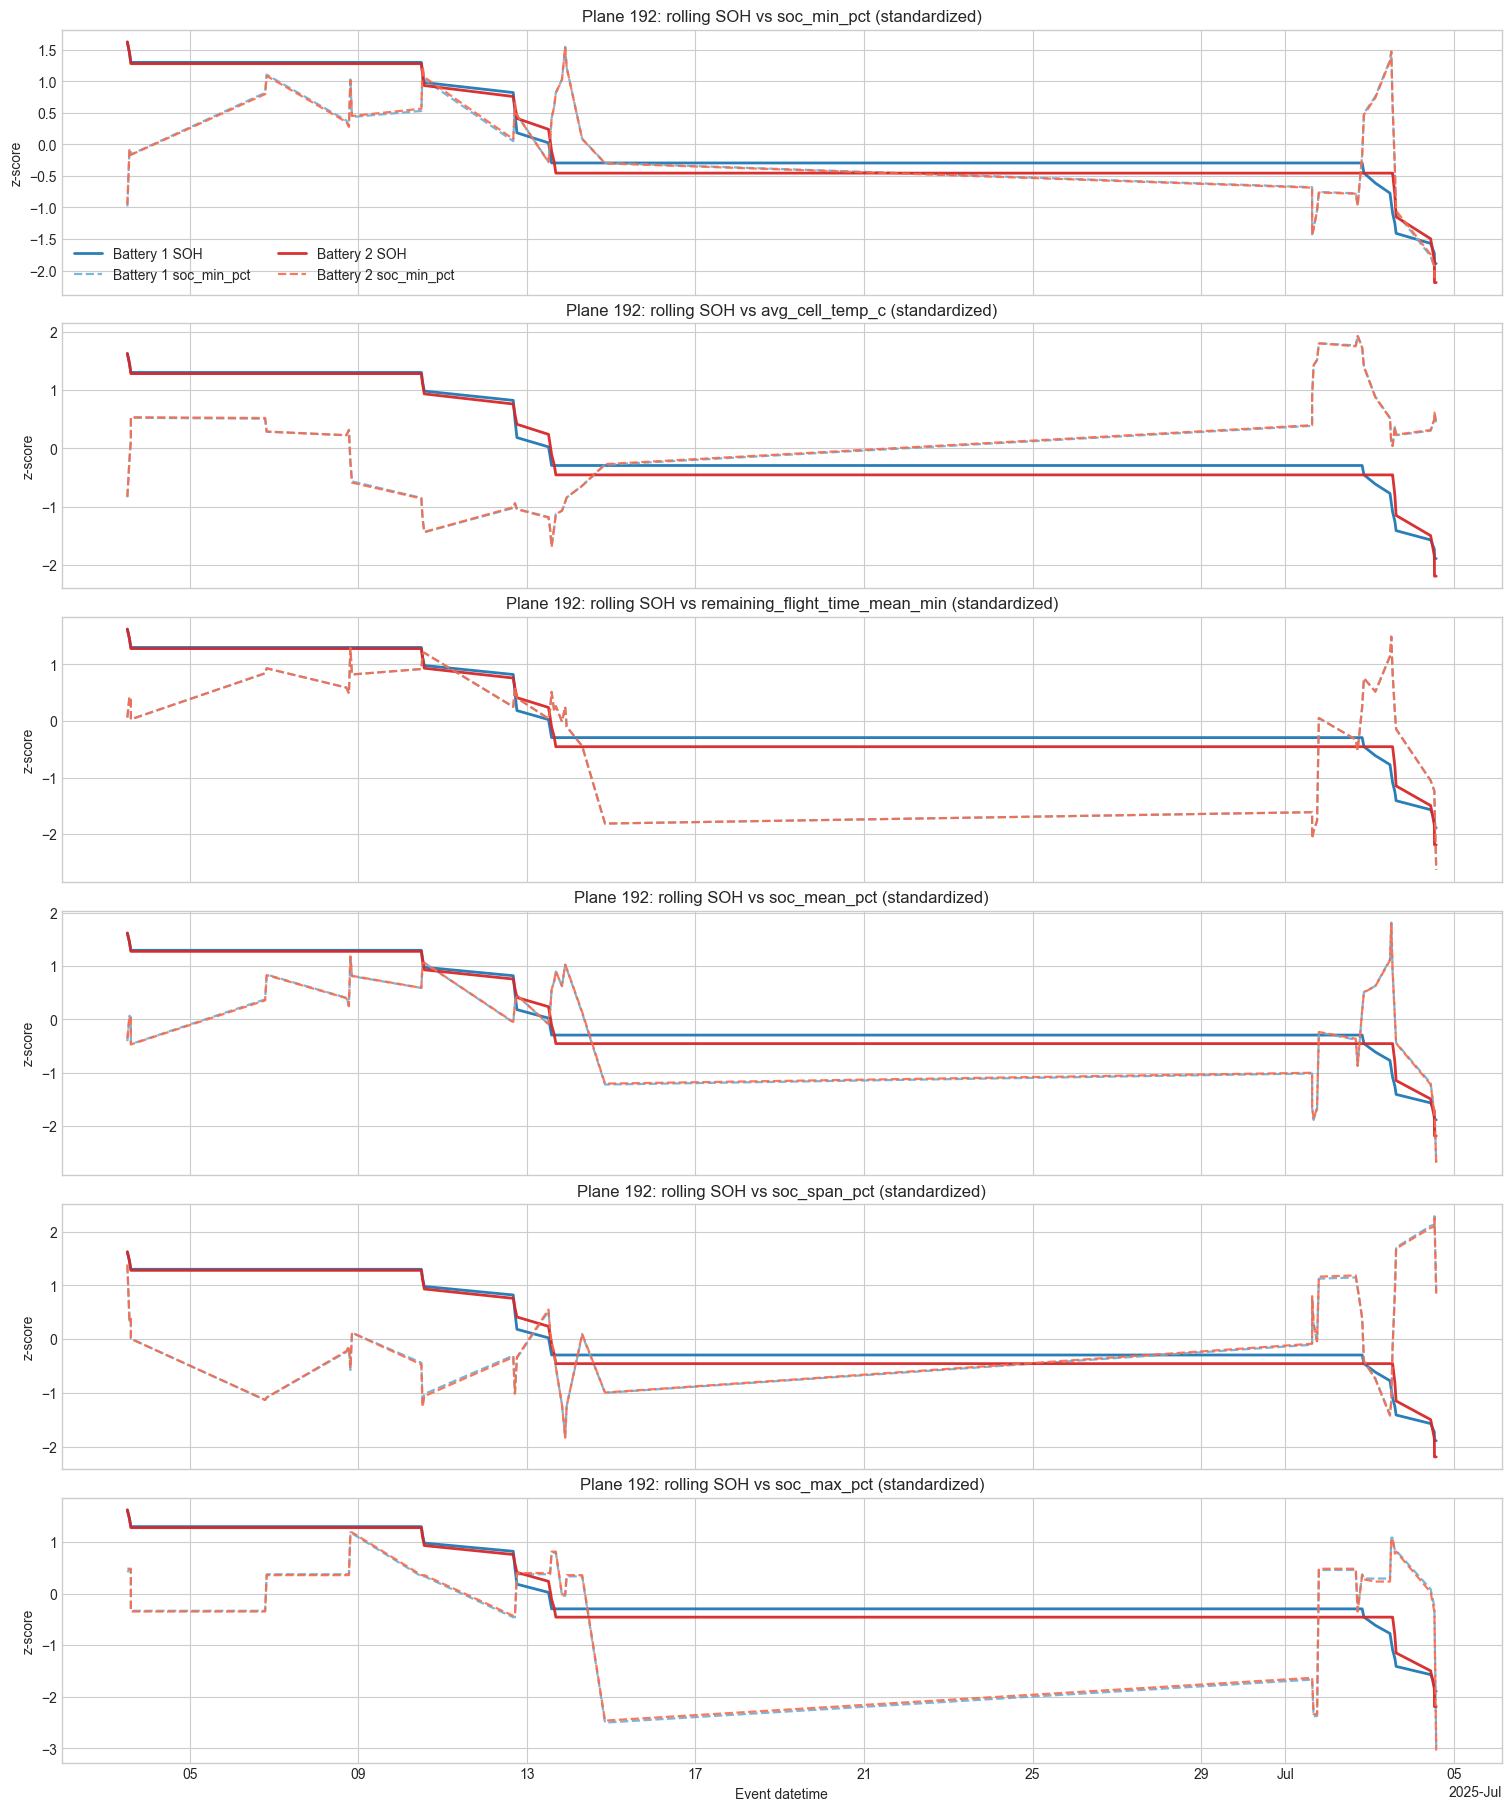

In [46]:
smoothed = event_df.copy()
for metric in ['observed_soh_pct', *metrics_to_plot]:
    smoothed[f'{metric}_roll'] = (
        smoothed.groupby(['plane_id', 'battery_id'])[metric]
        .transform(lambda s: pd.to_numeric(s, errors='coerce').rolling(ROLLING_WINDOW, center=True, min_periods=max(5, ROLLING_WINDOW // 3)).mean())
    )
    smoothed[f'{metric}_roll_z'] = smoothed.groupby(['plane_id', 'battery_id'])[f'{metric}_roll'].transform(zscore)

for plane_id in PLANES:
    plane = smoothed.loc[smoothed['plane_id'] == plane_id].copy()
    fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(15, 3 * len(metrics_to_plot)), sharex=True, constrained_layout=True)
    if len(metrics_to_plot) == 1:
        axes = [axes]
    for ax, metric in zip(axes, metrics_to_plot):
        for battery_id, group in plane.groupby('battery_id'):
            group = group.sort_values('event_datetime')
            ax.plot(group['event_datetime'], group['observed_soh_pct_roll_z'], color='#1f77b4' if battery_id == 1 else '#d62728', linewidth=2.0, alpha=0.95, label=f'Battery {battery_id} SOH' if metric == metrics_to_plot[0] else None)
            ax.plot(group['event_datetime'], group[f'{metric}_roll_z'], color='#6baed6' if battery_id == 1 else '#fb6a4a', linestyle='--', linewidth=1.6, alpha=0.9, label=f'Battery {battery_id} {metric}' if metric == metrics_to_plot[0] else None)
        ax.set_title(f'Plane {plane_id}: rolling SOH vs {metric} (standardized)')
        ax.set_ylabel('z-score')
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    axes[0].legend(loc='best', ncol=2)
    axes[-1].set_xlabel('Event datetime')
    plt.show()


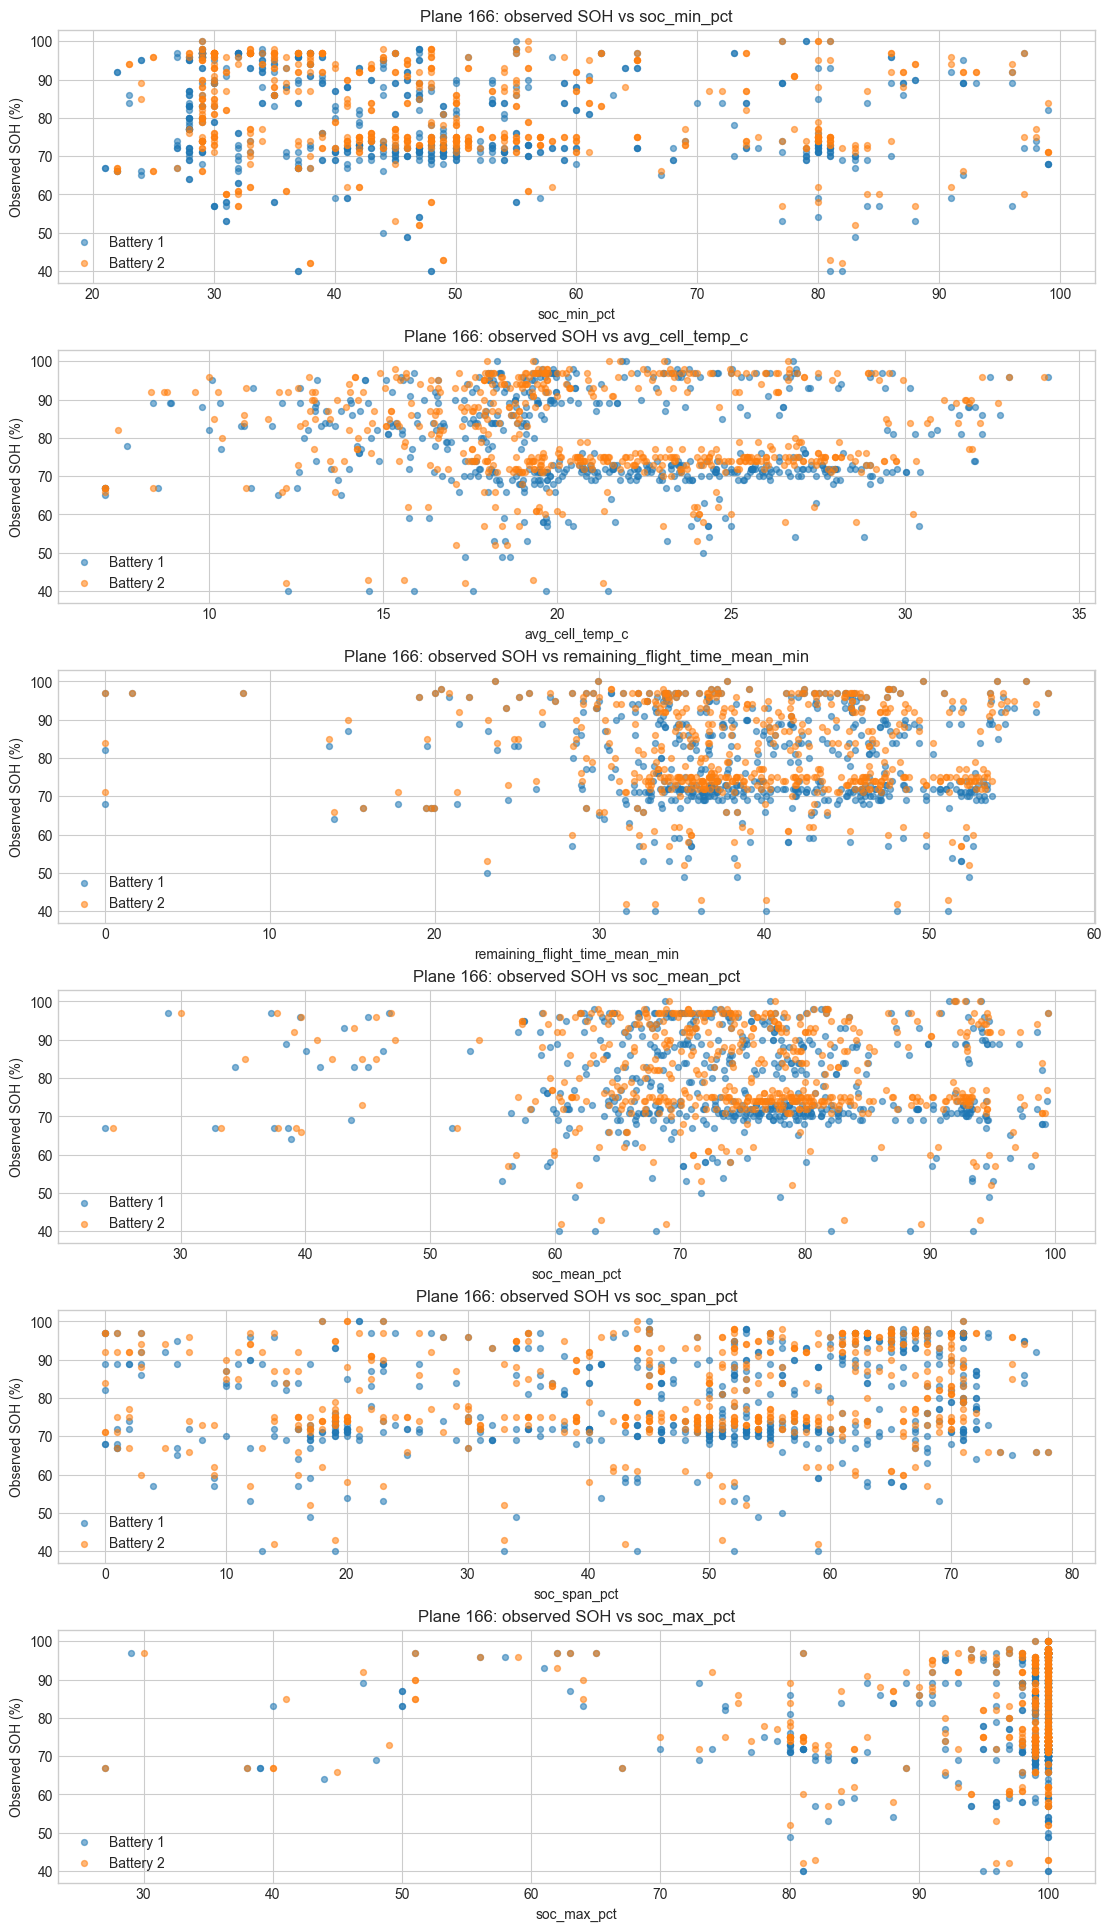

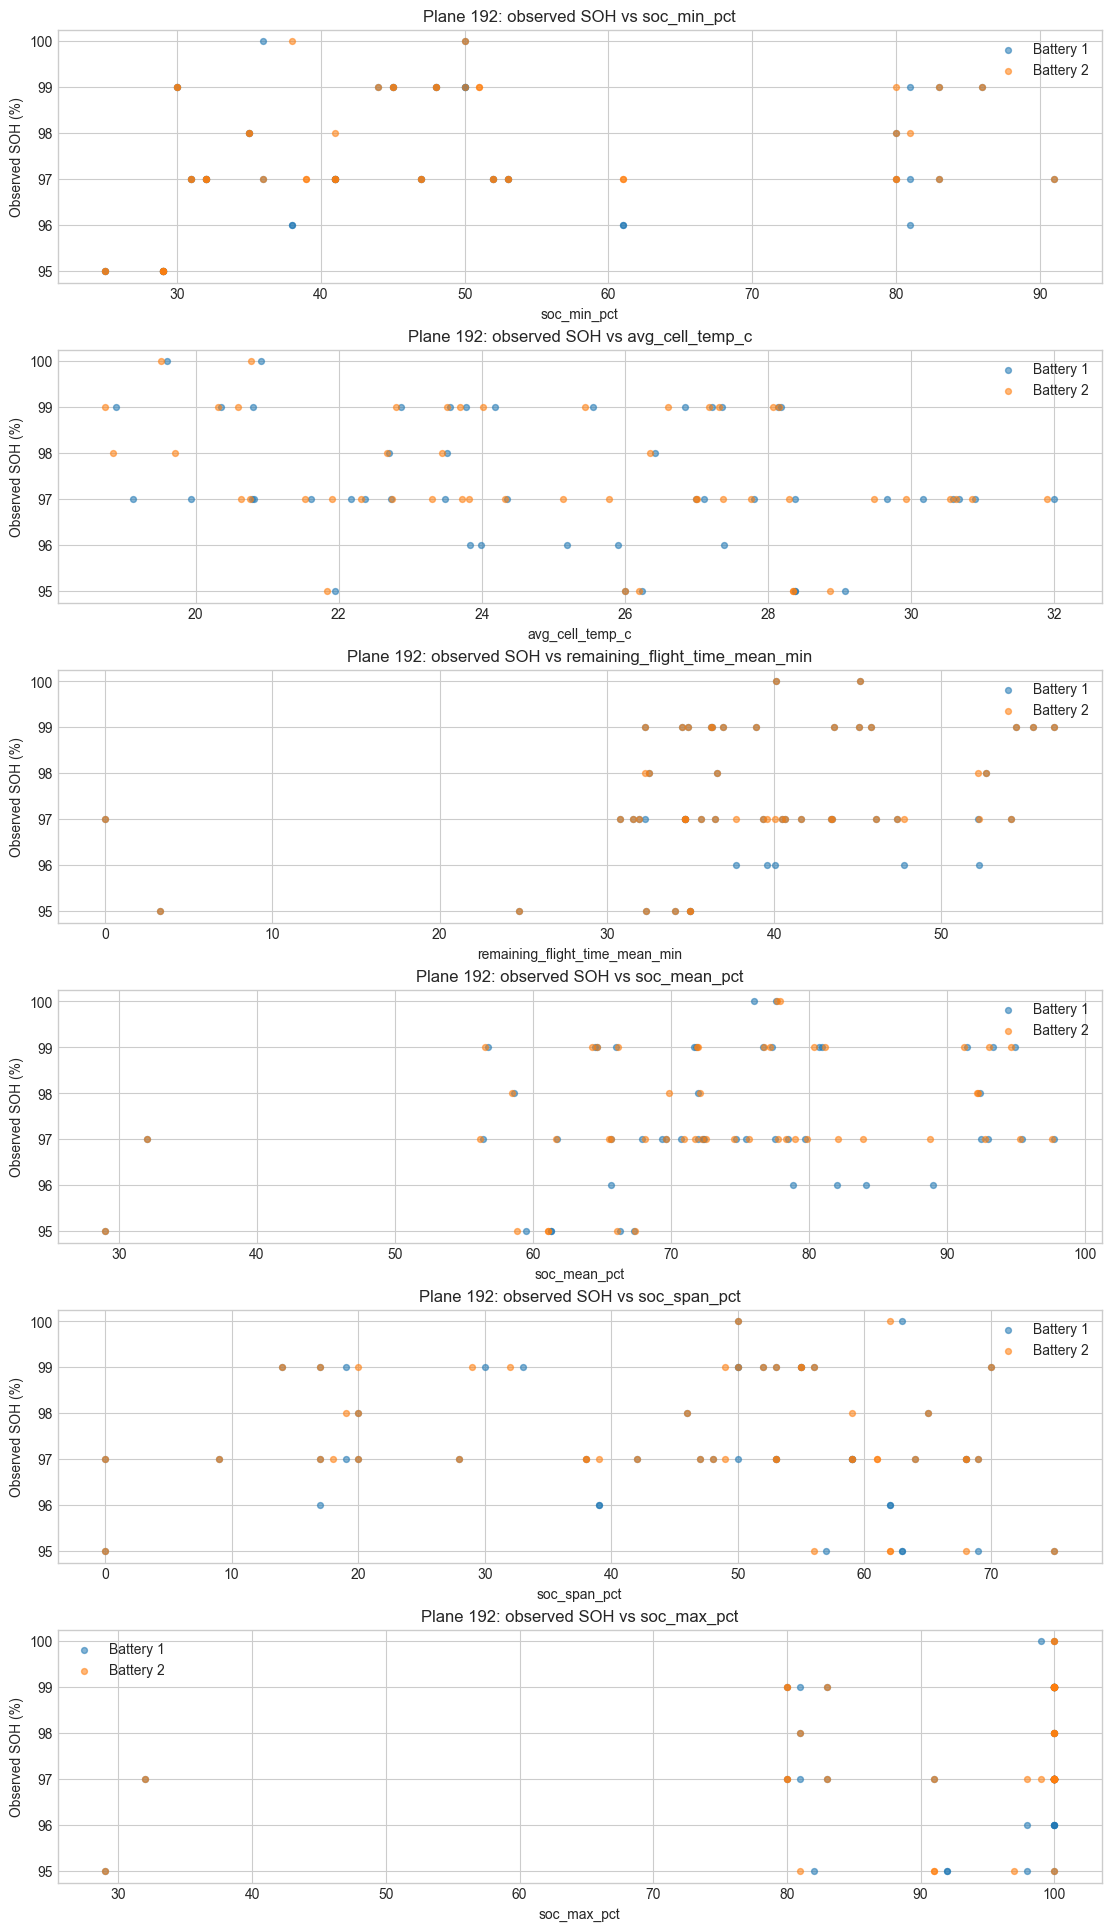

In [47]:
for plane_id in PLANES:
    plane = event_df.loc[event_df['plane_id'] == plane_id].copy()
    fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(11, 3.2 * len(metrics_to_plot)), constrained_layout=True)
    if len(metrics_to_plot) == 1:
        axes = [axes]
    for ax, metric in zip(axes, metrics_to_plot):
        for battery_id, group in plane.groupby('battery_id'):
            ax.scatter(group[metric], group['observed_soh_pct'], s=18, alpha=0.55, label=f'Battery {battery_id}')
        ax.set_title(f'Plane {plane_id}: observed SOH vs {metric}')
        ax.set_xlabel(metric)
        ax.set_ylabel('Observed SOH (%)')
        ax.legend(loc='best')
    plt.show()


## How To Use This Notebook

Focus on variables that satisfy both of these:
- They rank near the top of `corr_df` or `top_metrics`
- Their rolling standardized series rises and falls with SOH in the time-series plots

A variable is more plausible as a driver of the SOH spikes if:
- It moves at the same dates as the SOH jumps for both batteries
- It has the same sign and similar strength across planes and batteries
- The scatter plots show a coherent trend instead of a diffuse cloud

If the top variables are mostly charging/SOC/voltage related rather than temperature related, that would support the hypothesis that the spikes are driven by charging regime or estimator behavior rather than ambient conditions.

## Jot Notes

- Strongest feature signal in this run: `soc_min_pct`
- Other top features are also mostly SOC/state variables: `soc_mean_pct`, `soc_span_pct`, `soc_max_pct`
- `remaining_flight_time_mean_min` also ranks relatively high, so flight-state context appears to matter
- `avg_cell_temp_c` has some relationship with SOH, but it is not the strongest driver
- `oat_mean_c` is weaker than the main SOC features, so ambient temperature is not the best explanation
- Voltage features matter somewhat, but they still rank below the strongest SOC features
- Current, motor power, IAS, inverter temp, and motor temp are weaker signals in this feature set

## How We Will Use This

- Treat raw observed SOH as condition-dependent, not as a clean health label by itself
- Prioritize SOC-context variables as correction features before trying temperature-only correction
- Build a first-pass normalization model using features like `soc_min_pct`, `soc_mean_pct` or `soc_span_pct`, and `remaining_flight_time_mean_min`
- Keep `avg_cell_temp_c` as a secondary correction term rather than the main driver
- Compare raw SOH vs corrected SOH to see whether the spikes collapse into a smoother trend
- If the corrected series is much smoother, use that corrected signal as a stronger SOH label candidate for downstream modeling

## First-Pass SOH Normalization

We will normalize observed SOH with a small set of candidate drivers rather than every top-ranked feature.

Chosen features:
- `soc_min_pct`
- `soc_span_pct`
- `remaining_flight_time_mean_min`
- `avg_cell_temp_c`

Why these make sense:
- `soc_min_pct` captures where in the SOC window the event spends time
- `soc_span_pct` captures how much SOC movement occurs during the event
- `remaining_flight_time_mean_min` captures flight-state and estimator context
- `avg_cell_temp_c` is kept as a secondary operating-condition term

Why we are not using all SOC variables together:
- `soc_min_pct`, `soc_mean_pct`, `soc_max_pct`, and `soc_span_pct` are strongly related to each other
- putting all of them into one linear model would create redundancy and unstable coefficients
- this first-pass model uses a smaller, more interpretable subset


In [48]:
normalization_features = [
    'soc_min_pct',
    'soc_span_pct',
    'remaining_flight_time_mean_min',
    'avg_cell_temp_c',
]


def fit_linear_normalizer(g: pd.DataFrame, feature_cols: list[str]):
    work = g.copy().sort_values('event_datetime').reset_index(drop=True)
    y = pd.to_numeric(work['observed_soh_pct'], errors='coerce')
    X = work[feature_cols].apply(pd.to_numeric, errors='coerce')
    valid = y.notna() & X.notna().all(axis=1)
    fit_df = work.loc[valid].copy()
    if len(fit_df) < len(feature_cols) + 3:
        work['soh_norm_regressed_pct'] = pd.to_numeric(work['observed_soh_pct'], errors='coerce')
        return work, {'n_fit': int(len(fit_df))}

    X_fit = fit_df[feature_cols].apply(pd.to_numeric, errors='coerce')
    y_fit = pd.to_numeric(fit_df['observed_soh_pct'], errors='coerce')
    refs = X_fit.median()
    X_centered = X_fit - refs
    design = np.column_stack([np.ones(len(X_centered)), X_centered.to_numpy(dtype=float)])
    beta, _, _, _ = np.linalg.lstsq(design, y_fit.to_numpy(dtype=float), rcond=None)

    X_all = work[feature_cols].apply(pd.to_numeric, errors='coerce')
    X_all_centered = X_all - refs
    effect = pd.Series(beta[0], index=work.index, dtype='float64')
    for i, col in enumerate(feature_cols, start=1):
        effect = effect + beta[i] * X_all_centered[col]
        work[f'{col}_ref'] = refs[col]
        work[f'beta_{col}'] = beta[i]

    work['intercept_at_reference'] = beta[0]
    work['modeled_soh_pct'] = effect
    work['soh_norm_regressed_pct'] = pd.to_numeric(work['observed_soh_pct'], errors='coerce') - (effect - beta[0])

    summary = {'n_fit': int(len(fit_df)), 'intercept_at_reference': float(beta[0])}
    for i, col in enumerate(feature_cols, start=1):
        summary[f'beta_{col}'] = float(beta[i])
        summary[f'ref_{col}'] = float(refs[col])
    return work, summary


normalized_parts = []
normalizer_rows = []
for (plane_id, battery_id), g in event_df.groupby(['plane_id', 'battery_id']):
    adjusted, summary = fit_linear_normalizer(g, normalization_features)
    adjusted['plane_id'] = plane_id
    adjusted['battery_id'] = battery_id
    summary['plane_id'] = plane_id
    summary['battery_id'] = battery_id
    normalized_parts.append(adjusted)
    normalizer_rows.append(summary)

normalized_df = pd.concat(normalized_parts, ignore_index=True).sort_values(['plane_id', 'battery_id', 'event_datetime']).reset_index(drop=True)
normalizer_summary = pd.DataFrame(normalizer_rows)
normalizer_summary


,n_fit,intercept_at_reference,beta_soc_min_pct,ref_soc_min_pct,beta_soc_span_pct,ref_soc_span_pct,beta_remaining_flight_time_mean_min,ref_remaining_flight_time_mean_min,beta_avg_cell_temp_c,ref_avg_cell_temp_c,plane_id,battery_id
0,555,79.503979,0.000279,45.0,0.094076,52.0,-0.055857,38.931934,-0.159607,20.413073,166,1
1,555,81.844690,0.009735,46.0,0.099122,51.0,-0.034353,38.931934,-0.147272,20.154044,166,2
2,49,97.294620,-0.041848,45.0,-0.026197,50.0,0.083411,37.708376,-0.102258,25.197233,192,1
3,49,97.433614,-0.026911,45.0,-0.017479,50.0,0.071219,37.708376,-0.112337,25.138305,192,2


In [49]:
normalization_effect = (
    normalized_df.groupby(['plane_id', 'battery_id'], as_index=False)
    .agg(
        n_points=('observed_soh_pct', 'size'),
        raw_std=('observed_soh_pct', 'std'),
        norm_std=('soh_norm_regressed_pct', 'std'),
        raw_range=('observed_soh_pct', lambda s: pd.to_numeric(s, errors='coerce').max() - pd.to_numeric(s, errors='coerce').min()),
        norm_range=('soh_norm_regressed_pct', lambda s: pd.to_numeric(s, errors='coerce').max() - pd.to_numeric(s, errors='coerce').min()),
    )
)
normalization_effect['std_reduction_pct'] = 100.0 * (1.0 - normalization_effect['norm_std'] / normalization_effect['raw_std'])
normalization_effect['range_reduction_pct'] = 100.0 * (1.0 - normalization_effect['norm_range'] / normalization_effect['raw_range'])
normalization_effect


,plane_id,battery_id,n_points,raw_std,norm_std,raw_range,norm_range,std_reduction_pct,range_reduction_pct
0,166,1,555,12.378100,12.184588,60.0,66.089613,1.563342,-10.149355
1,166,2,555,11.854003,11.683172,58.0,63.319368,1.441130,-9.171324
2,192,1,49,1.409697,1.278680,5.0,4.633097,9.293950,7.338059
3,192,2,49,1.340436,1.173189,5.0,4.560241,12.477093,8.795187


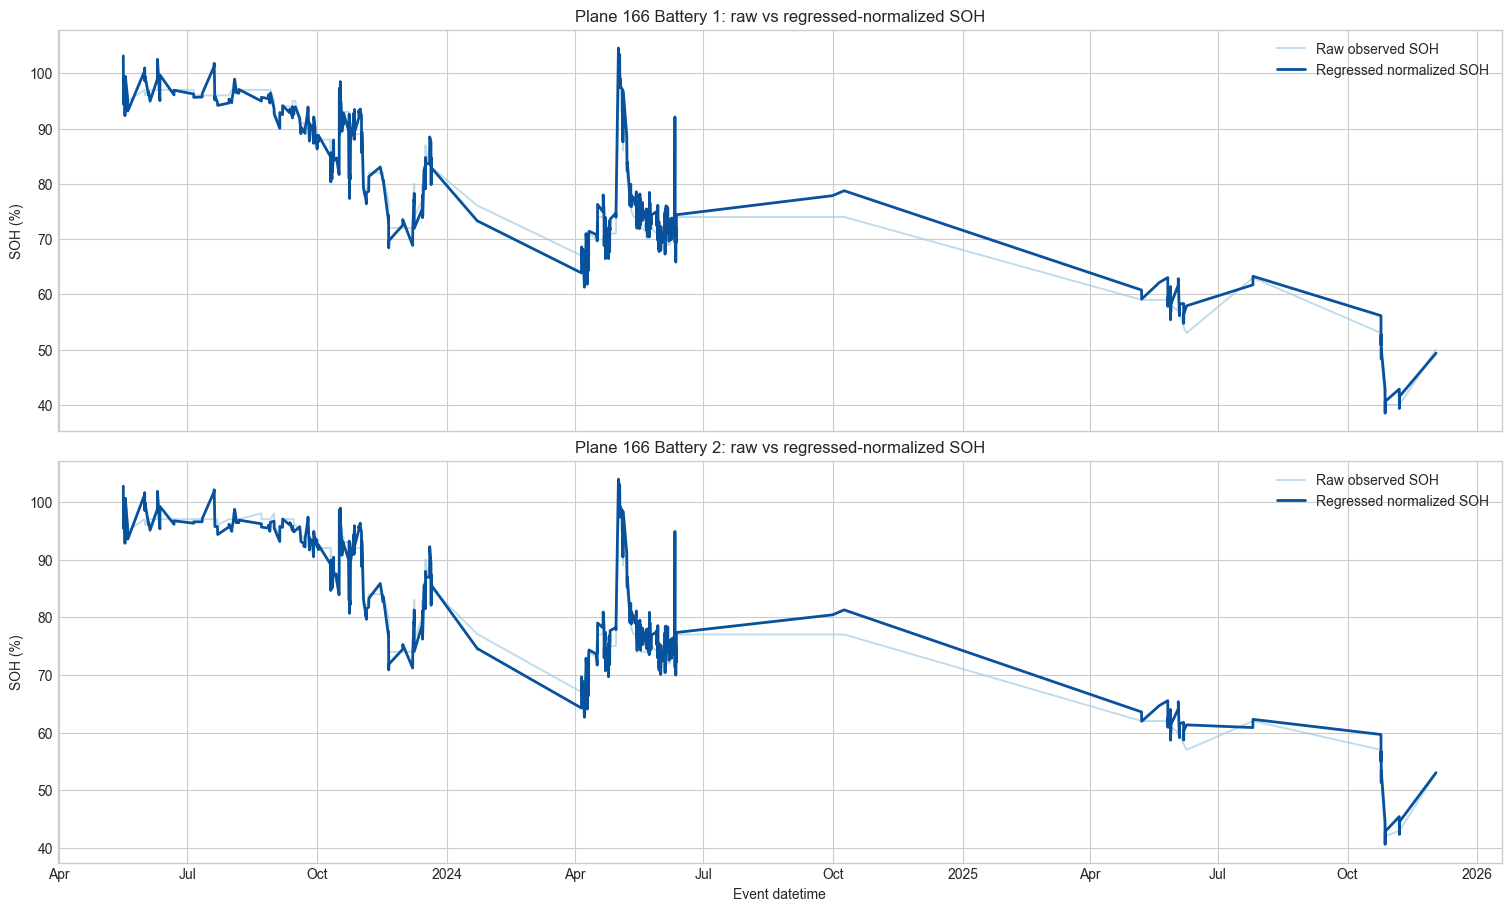

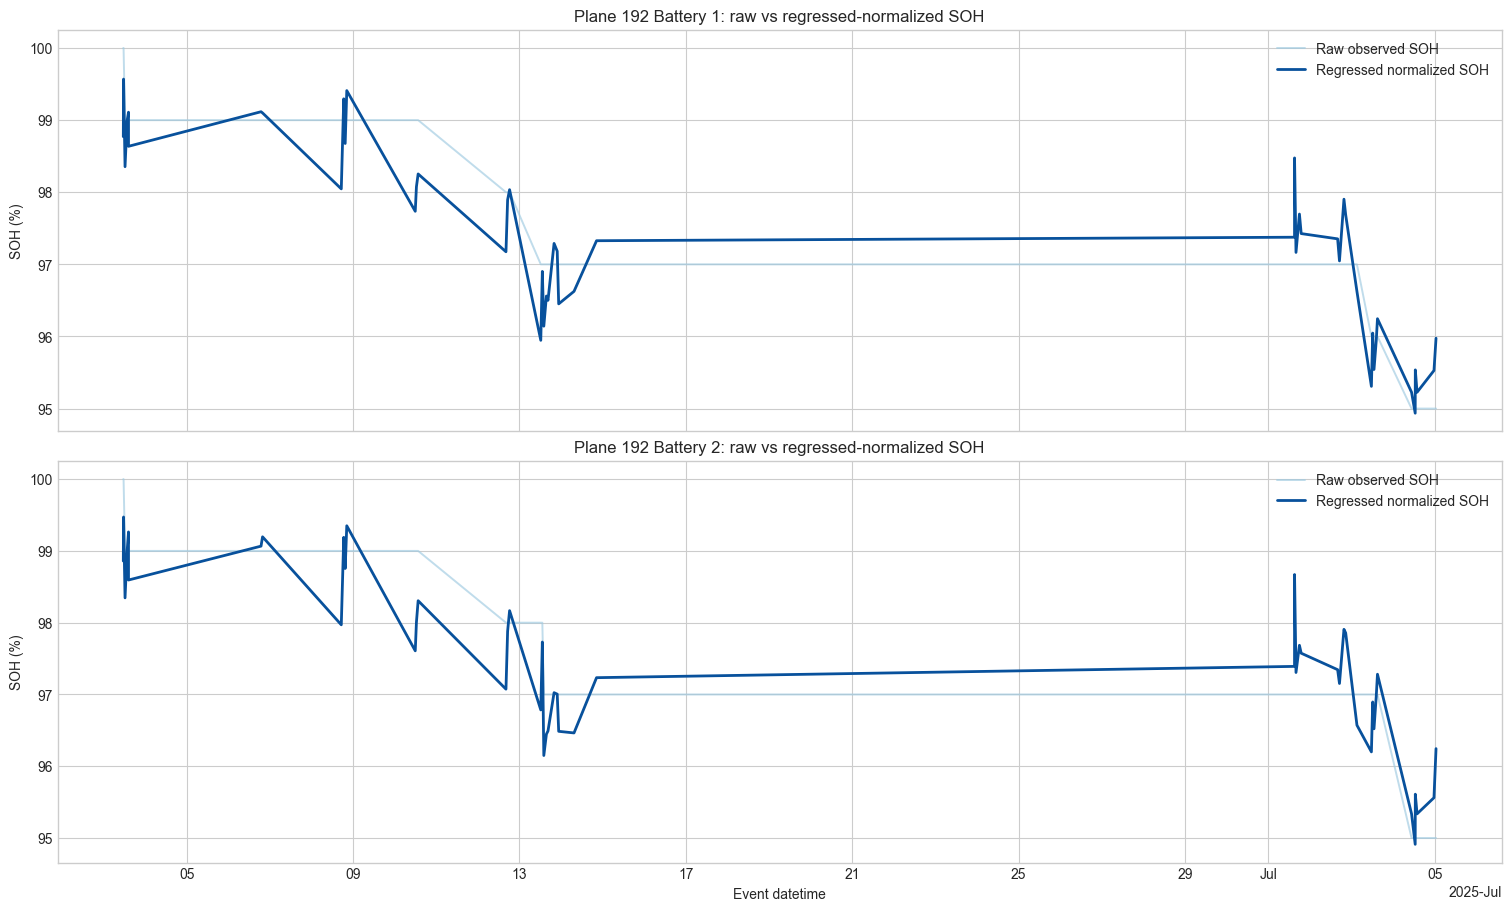

In [50]:
for plane_id in PLANES:
    plane = normalized_df.loc[normalized_df['plane_id'] == plane_id].copy()
    fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True, constrained_layout=True)
    for ax, battery_id in zip(axes, sorted(plane['battery_id'].unique())):
        g = plane.loc[plane['battery_id'] == battery_id].sort_values('event_datetime')
        ax.plot(g['event_datetime'], g['observed_soh_pct'], color='#9ecae1', linewidth=1.4, alpha=0.65, label='Raw observed SOH')
        ax.plot(g['event_datetime'], g['soh_norm_regressed_pct'], color='#08519c', linewidth=2.0, label='Regressed normalized SOH')
        ax.set_title(f'Plane {plane_id} Battery {battery_id}: raw vs regressed-normalized SOH')
        ax.set_ylabel('SOH (%)')
        ax.legend(loc='best')
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    axes[-1].set_xlabel('Event datetime')
    plt.show()


## Do These Variables Make Sense To Normalize Against?

Yes, with some care.

Why they make sense:
- They are among the strongest non-time correlates of observed SOH in this dataset
- They describe operating context and estimator state, not permanent battery-health change
- That makes them reasonable candidates for removing condition-dependent variation from raw observed SOH

Why we should still be cautious:
- This is a correlation-based normalization, not proof of causal physics
- SOC variables are partially redundant, so coefficient size should not be over-interpreted
- If the corrected series becomes smoother but loses obvious long-term structure, the model may be over-correcting

How to judge whether the normalization is useful:
- The normalized SOH should reduce obvious short-term spikes
- It should preserve slower long-term degradation behavior
- It should look more consistent across both batteries on the same plane
- It should not introduce new artificial jumps
